### Implement and evaluate Random Forest for classification in a business-intelligence context.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

np.random.seed(42)

#### Load Dataset

In [ ]:
from google.colab import files
data = files.upload()

Saving Social_Network_Ads.csv to Social_Network_Ads (1).csv


In [ ]:
df = pd.read_csv('Social_Network_Ads.csv')

df = pd.DataFrame(df)
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


,0
User ID,0
Gender,0
Age,0
EstimatedSalary,0
Purchased,0


#### Preprocessing

In [ ]:
df = df.drop(columns=['User ID'], errors='ignore').dropna()

if 'Gender' in df.columns:
    le = LabelEncoder()
    df['Gender'] = le.fit_transform(df['Gender'])

X = df.drop('Purchased', axis=1)
y = df['Purchased']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print('Train shape:', X_train.shape)
print('Test shape :', X_test.shape)

Train shape: (320, 3)
Test shape : (80, 3)


#### Train Baseline Random Forest

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print('Baseline Accuracy:', accuracy_score(y_test, y_pred))
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred))

Baseline Accuracy: 0.9

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.90      0.92        51
           1       0.84      0.90      0.87        29

    accuracy                           0.90        80
   macro avg       0.89      0.90      0.89        80
weighted avg       0.90      0.90      0.90        80



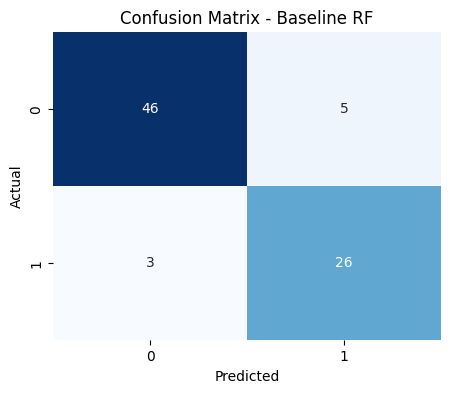

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Baseline RF')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### Hyperparameter Tuning

In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid.fit(X_train, y_train)

print('Best Params:', grid.best_params_)
print('Best CV Accuracy:', grid.best_score_)

Best Params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Accuracy: 0.903125


In [ ]:
best_rf = grid.best_estimator_
best_pred = best_rf.predict(X_test)

print('Test Accuracy (Best Model):', accuracy_score(y_test, best_pred))
print('\nClassification Report (Best Model):\n')
print(classification_report(y_test, best_pred))

Test Accuracy (Best Model): 0.9

Classification Report (Best Model):

              precision    recall  f1-score   support

           0       0.94      0.90      0.92        51
           1       0.84      0.90      0.87        29

    accuracy                           0.90        80
   macro avg       0.89      0.90      0.89        80
weighted avg       0.90      0.90      0.90        80

